Pipeline steps: 
0) convert to lower case, remove emojis, punctuation, special characters
1) remove stop words 
2) lemmetization (no stemming)
3) vectorize (TF-IDF) 
4) Normalize labels? I think not...what would that achieve 

In [20]:
# Imports
import sklearn
import pandas as pd
import numpy as np

# Data Exploration

In [21]:
dataframe = pd.read_csv('data_labeled.csv')
dataframe.columns = ["sentence", "label"]
print(dataframe.head())
print(dataframe.describe())


                                            sentence  label
0                                              Today      1
1  I want to print the occasion and a photo on th...      1
2  When I will get, how many days it will take to...      1
3                                           Delivery      1
4    I want gift suggestion for general in all gifts      2
             label
count  1084.000000
mean      1.153137
std       1.089944
min      -2.000000
25%       1.000000
50%       1.000000
75%       2.000000
max       2.000000


Label Distribution:
label
-2     49
-1     93
 1    443
 2    499
Name: count, dtype: int64

Total samples: 1084


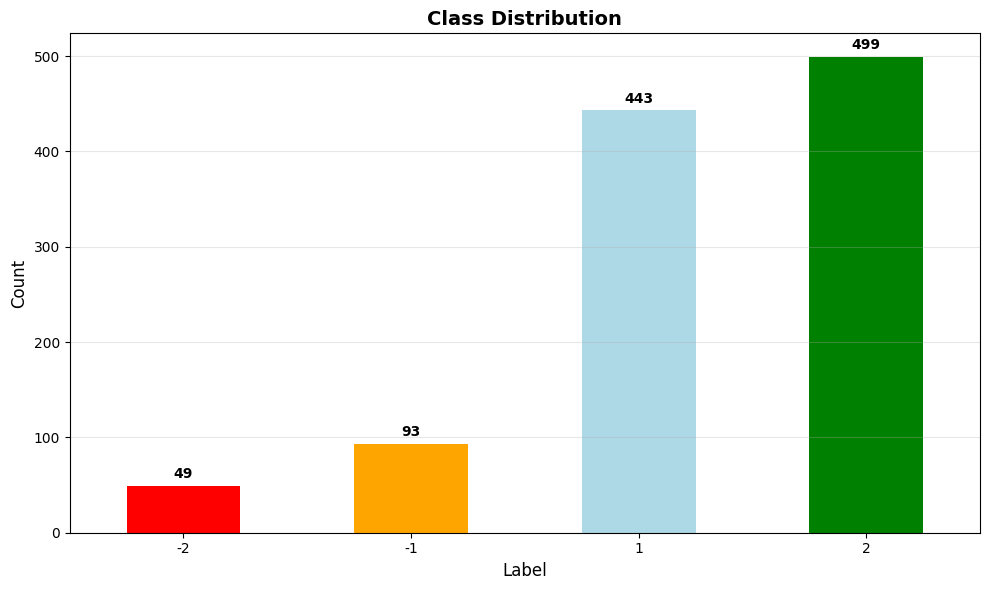


Label Meanings:
-2: Escalate to human agent
-1: Track order/order status (login required)
 1: General conversation/company policy
 2: Product recommendation


In [22]:
import matplotlib.pyplot as plt

# Count label distribution
label_counts = dataframe['label'].value_counts().sort_index()
print("Label Distribution:")
print(label_counts)
print(f"\nTotal samples: {len(dataframe)}")

# Create bar plot
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color=['red', 'orange', 'lightblue', 'green'])
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print label meanings
print("\nLabel Meanings:")
print("-2: Escalate to human agent")
print("-1: Track order/order status (login required)")
print(" 1: General conversation/company policy")
print(" 2: Product recommendation")

# Pipeline

In [23]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✓ NLTK resources downloaded")

✓ NLTK resources downloaded


In [24]:
def preprocess_text(text):
    """
    Preprocess text with the following steps:
    0) Convert to lowercase, remove emojis, punctuation, special characters
    1) Remove stop words
    2) Lemmatization
    """
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove emojis and special characters, keep only alphanumeric and spaces
    # This preserves English and other Unicode letters
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove English stop words
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 1]
    
    # Lemmatization (only works well for English words)
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(words)

# Test the function
sample_text = "I want gift suggestion for wife in all gifts"
print(f"Original: {sample_text}")
print(f"Processed: {preprocess_text(sample_text)}")
print()

sample_text2 = "Hello, do you deliver to pincode 560001?"
print(f"Original: {sample_text2}")
print(f"Processed: {preprocess_text(sample_text2)}")

Original: I want gift suggestion for wife in all gifts
Processed: want gift suggestion wife gift

Original: Hello, do you deliver to pincode 560001?
Processed: hello deliver pincode 560001


In [25]:
# Apply preprocessing to all sentences
print("Preprocessing all sentences...")
dataframe['processed_sentence'] = dataframe['sentence'].apply(preprocess_text)

# Show before and after examples
print("\nBefore and After Preprocessing (first 10 rows):")
print("="*80)
for idx in range(min(10, len(dataframe))):
    print(f"\nOriginal: {dataframe['sentence'].iloc[idx]}")
    print(f"Processed: {dataframe['processed_sentence'].iloc[idx]}")
    print("-"*80)

print(f"\n✓ Preprocessing complete! Total samples: {len(dataframe)}")

Preprocessing all sentences...

Before and After Preprocessing (first 10 rows):

Original: Today
Processed: today
--------------------------------------------------------------------------------

Original: I want to print the occasion and a photo on the cover page
Processed: want print occasion photo cover page
--------------------------------------------------------------------------------

Original: When I will get, how many days it will take to reach me . I live in Banglore
Processed: get many day take reach live banglore
--------------------------------------------------------------------------------

Original: Delivery
Processed: delivery
--------------------------------------------------------------------------------

Original: I want gift suggestion for general in all gifts
Processed: want gift suggestion general gift
--------------------------------------------------------------------------------

Original: location
Processed: location
------------------------------------------

## TF-IDF Vectorization

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,          # Limit to top 5000 features
    min_df=2,                   # Word must appear in at least 2 documents
    max_df=0.8,                 # Word can't appear in more than 80% of documents
    ngram_range=(1, 2),         # Use unigrams and bigrams
    lowercase=False             # Already lowercased in preprocessing
)

# Fit and transform the processed sentences
X = tfidf_vectorizer.fit_transform(dataframe['processed_sentence'])
y = dataframe['label'].values

print(f"✓ TF-IDF Vectorization Complete!")
print(f"Shape of feature matrix: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nVocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"\nSample feature names: {tfidf_vectorizer.get_feature_names_out()[:20]}")

✓ TF-IDF Vectorization Complete!
Shape of feature matrix: (1084, 603)
Number of samples: 1084
Number of features: 603

Vocabulary size: 603

Sample feature names: ['500' 'able' 'able add' 'accept' 'accept gift' 'accessory' 'account'
 'activate' 'activity' 'add' 'add cart' 'address' 'address change'
 'address order' 'affordable' 'agent' 'agent needed' 'anniversary'
 'anything' 'app']


In [27]:
# Examine the most important features for each class
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Top TF-IDF weighted words by class:\n")
for label in sorted(dataframe['label'].unique()):
    # Get indices for this label
    label_indices = dataframe['label'] == label
    
    # Get mean TF-IDF scores for this class
    mean_tfidf = X[label_indices.values].mean(axis=0).A1
    
    # Get top 10 features
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    
    label_name = {-2: "Escalate to agent", -1: "Track order", 1: "General/Policy", 2: "Product recommendation"}
    print(f"Label {label} ({label_name[label]}): {', '.join(top_words)}")
    print()

Top TF-IDF weighted words by class:

Label -2 (Escalate to agent): call, contact, need, talk, agent, person, number, issue, someone, complaint

Label -1 (Track order): order, cancel, cancel order, change, need, delivery, address, track, track order, want cancel

Label 1 (General/Policy): delivery, order, available, want, get, time, gift, product, deliver, card

Label 2 (Product recommendation): gift, want, suggestion, want gift, gift suggestion, something, looking, birthday, need, product



In [28]:
# X is the TF-IDF feature matrix where each row corresponds to a sentence and each column to a TF-IDF feature
# We have a vocabulary of 347 features : so , 347 columns
# We have total 604 sentences, so total 604 rows

print(X.shape)

(1084, 603)


# Training

In [29]:
# Show first 5 rows of X (sparse matrix representation)
print("Sparse matrix representation (first 5 rows):")
print(X[:5])
print("\n" + "="*80 + "\n")

# Show as dense array to see actual values
print("Dense array representation (first 5 rows, first 20 features):")
print(X[:5, :20].toarray())
print("\nNote: Most values are 0 (sparse matrix), only non-zero TF-IDF scores are shown.")

Sparse matrix representation (first 5 rows):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24 stored elements and shape (5, 603)>
  Coords	Values
  (0, 523)	1.0
  (1, 556)	0.19598318129216735
  (1, 406)	0.5418841467891077
  (1, 384)	0.4009807823044888
  (1, 103)	0.4873752846894411
  (1, 367)	0.5192609249747268
  (2, 183)	0.24461360231424584
  (2, 293)	0.32812089422900104
  (2, 123)	0.23605506280904273
  (2, 508)	0.301165204989687
  (2, 420)	0.38257713093951434
  (2, 274)	0.3666048472961574
  (2, 28)	0.38257713093951434
  (2, 294)	0.33553463836715486
  (2, 125)	0.38257713093951434
  (3, 135)	1.0
  (4, 556)	0.2016246649744625
  (4, 188)	0.4012720340344817
  (4, 493)	0.24773266108518033
  (4, 181)	0.43885099740229244
  (4, 562)	0.2367830925065138
  (4, 201)	0.25903987057297906
  (4, 499)	0.43885099740229244
  (4, 182)	0.47813020666135775


Dense array representation (first 5 rows, first 20 features):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0.

In [30]:
from sklearn.model_selection import train_test_split

# Split data with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 80-20 split
    random_state=42,         # For reproducibility
    stratify=y               # Maintain class distribution
)

print("✓ Train-Test Split Complete!")
print(f"\nTotal samples: {X.shape[0]}")
print(f"Training samples: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Testing samples: {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")

# Check class distribution in train and test sets
print("\n" + "="*80)
print("\nClass Distribution in Training Set:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for label in train_dist.index:
    label_name = {-2: "Escalate to agent", -1: "Track order", 1: "General/Policy", 2: "Product recommendation"}
    print(f"Label {label:2d} ({label_name[label]:25s}): {train_dist[label]:3d} samples ({train_dist[label]/len(y_train)*100:5.1f}%)")

print("\nClass Distribution in Testing Set:")
test_dist = pd.Series(y_test).value_counts().sort_index()
for label in test_dist.index:
    label_name = {-2: "Escalate to agent", -1: "Track order", 1: "General/Policy", 2: "Product recommendation"}
    print(f"Label {label:2d} ({label_name[label]:25s}): {test_dist[label]:3d} samples ({test_dist[label]/len(y_test)*100:5.1f}%)")

✓ Train-Test Split Complete!

Total samples: 1084
Training samples: 867 (80.0%)
Testing samples: 217 (20.0%)
Number of features: 603


Class Distribution in Training Set:
Label -2 (Escalate to agent        ):  39 samples (  4.5%)
Label -1 (Track order              ):  75 samples (  8.7%)
Label  1 (General/Policy           ): 354 samples ( 40.8%)
Label  2 (Product recommendation   ): 399 samples ( 46.0%)

Class Distribution in Testing Set:
Label -2 (Escalate to agent        ):  10 samples (  4.6%)
Label -1 (Track order              ):  18 samples (  8.3%)
Label  1 (General/Policy           ):  89 samples ( 41.0%)
Label  2 (Product recommendation   ): 100 samples ( 46.1%)


In [31]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

# XGBoost requires labels to be 0, 1, 2, 3... so we need to encode them
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Label mapping:")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    label_name = {-2: "Escalate to agent", -1: "Track order", 1: "General/Policy", 2: "Product recommendation"}
    print(f"  {original} ({label_name[original]:25s}) -> {encoded}")

# Calculate class weights to handle imbalance
classes = np.unique(y_train_encoded)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_encoded)
sample_weights = np.array([class_weights[np.where(classes == label)[0][0]] for label in y_train_encoded])

print("\nClass weights:", dict(zip(label_encoder.classes_, class_weights)))
print("\n" + "="*80)

# Initialize XGBoost classifier
xgb_model = XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=4,                # 4 classes (0, 1, 2, 3)
    max_depth=10,                # Maximum depth of trees
    learning_rate=0.1,          # Learning rate
    n_estimators=1000,           # Number of boosting rounds
    random_state=42,
    eval_metric='mlogloss',     # Multi-class log loss
    early_stopping_rounds=10    # Stop if no improvement for 10 rounds
)

print("\n✓ Training XGBoost model with early stopping...")
# Pass evaluation set for early stopping
xgb_model.fit(
    X_train, y_train_encoded,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test_encoded)],  # Monitor validation set
    verbose=True  # Show progress
)
print(f"✓ Training complete! Stopped at iteration {xgb_model.best_iteration}")

Label mapping:
  -2 (Escalate to agent        ) -> 0
  -1 (Track order              ) -> 1
  1 (General/Policy           ) -> 2
  2 (Product recommendation   ) -> 3

Class weights: {np.int64(-2): np.float64(5.5576923076923075), np.int64(-1): np.float64(2.89), np.int64(1): np.float64(0.6122881355932204), np.int64(2): np.float64(0.543233082706767)}


✓ Training XGBoost model with early stopping...
[0]	validation_0-mlogloss:1.32786
[1]	validation_0-mlogloss:1.27423
[2]	validation_0-mlogloss:1.23125
[3]	validation_0-mlogloss:1.19075
[4]	validation_0-mlogloss:1.15739
[5]	validation_0-mlogloss:1.12914
[6]	validation_0-mlogloss:1.10856
[7]	validation_0-mlogloss:1.08430
[8]	validation_0-mlogloss:1.06522
[9]	validation_0-mlogloss:1.04587
[10]	validation_0-mlogloss:1.02878
[11]	validation_0-mlogloss:1.01588
[12]	validation_0-mlogloss:1.00018
[13]	validation_0-mlogloss:0.98447
[14]	validation_0-mlogloss:0.97329
[15]	validation_0-mlogloss:0.96294
[16]	validation_0-mlogloss:0.95469
[17]	validation_

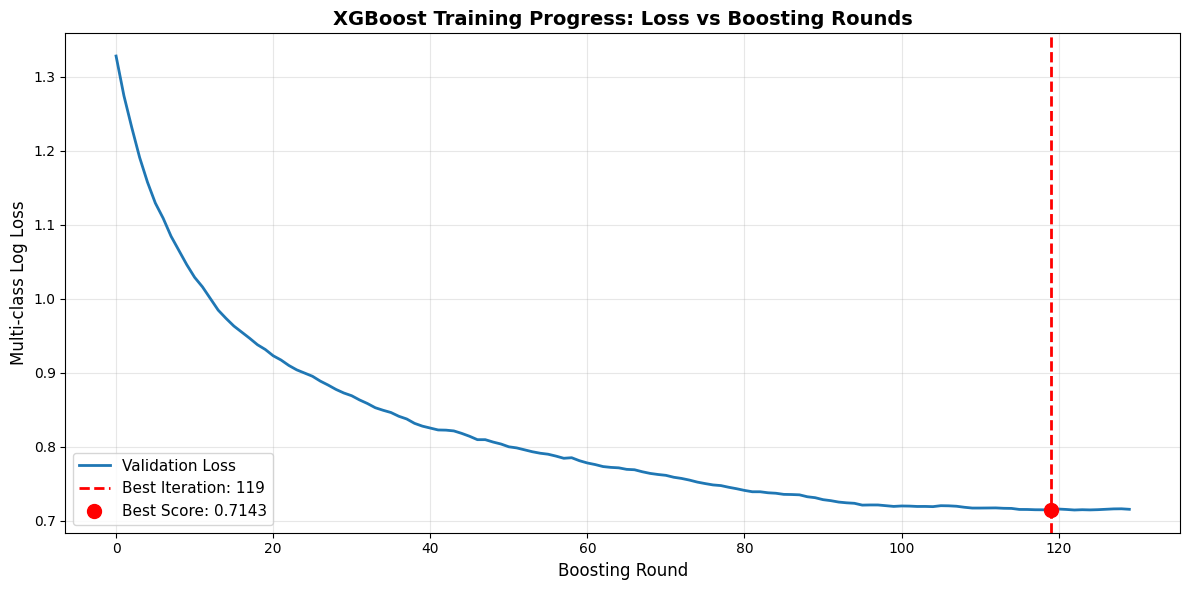


TRAINING ANALYSIS

Best Validation Loss: 0.7143 at iteration 119
Final Validation Loss: 0.7153

✓ Model training looks good - early stopping worked effectively


In [32]:
# Plot training and validation loss curves
results = xgb_model.evals_result()

plt.figure(figsize=(12, 6))

# Plot loss curves
plt.plot(results['validation_0']['mlogloss'], label='Validation Loss', linewidth=2)
plt.xlabel('Boosting Round', fontsize=12)
plt.ylabel('Multi-class Log Loss', fontsize=12)
plt.title('XGBoost Training Progress: Loss vs Boosting Rounds', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Mark the best iteration
if hasattr(xgb_model, 'best_iteration'):
    best_iter = xgb_model.best_iteration
    best_score = results['validation_0']['mlogloss'][best_iter]
    plt.axvline(x=best_iter, color='red', linestyle='--', linewidth=2, 
                label=f'Best Iteration: {best_iter}')
    plt.plot(best_iter, best_score, 'ro', markersize=10, label=f'Best Score: {best_score:.4f}')
    plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Analysis
print("\n" + "="*80)
print("TRAINING ANALYSIS")
print("="*80)
final_loss = results['validation_0']['mlogloss'][-1]
best_loss = min(results['validation_0']['mlogloss'])
best_iter = results['validation_0']['mlogloss'].index(best_loss)

print(f"\nBest Validation Loss: {best_loss:.4f} at iteration {best_iter}")
print(f"Final Validation Loss: {final_loss:.4f}")

if best_iter < len(results['validation_0']['mlogloss']) - 20:
    print("\n⚠️  Model might be OVERFITTING - best iteration was much earlier than the end")
elif final_loss > best_loss * 1.1:
    print("\n⚠️  Model shows signs of OVERFITTING - validation loss increased significantly")
elif best_iter >= len(results['validation_0']['mlogloss']) - 5:
    print("\n⚠️  Model might be UNDERFITTING - consider increasing n_estimators")
else:
    print("\n✓ Model training looks good - early stopping worked effectively")

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Make predictions on training and test sets (encoded labels)
y_train_pred_encoded = xgb_model.predict(X_train)
y_test_pred_encoded = xgb_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train_encoded, y_train_pred_encoded)
test_accuracy = accuracy_score(y_test_encoded, y_test_pred_encoded)

# Calculate F1 scores
train_f1_macro = f1_score(y_train_encoded, y_train_pred_encoded, average='macro')
test_f1_macro = f1_score(y_test_encoded, y_test_pred_encoded, average='macro')
train_f1_weighted = f1_score(y_train_encoded, y_train_pred_encoded, average='weighted')
test_f1_weighted = f1_score(y_test_encoded, y_test_pred_encoded, average='weighted')

print("="*80)
print("MODEL PERFORMANCE")
print("="*80)
print(f"\nTraining Set:")
print(f"  Accuracy:        {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  F1-Score (Macro):    {train_f1_macro:.4f}")
print(f"  F1-Score (Weighted): {train_f1_weighted:.4f}")

print(f"\nValidation/Test Set:")
print(f"  Accuracy:        {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  F1-Score (Macro):    {test_f1_macro:.4f}")
print(f"  F1-Score (Weighted): {test_f1_weighted:.4f}")

print("\n" + "="*80)
print("\nDetailed Classification Report (Test Set):")
print("="*80)
# Use original labels for reporting
y_test_pred_original = label_encoder.inverse_transform(y_test_pred_encoded)
label_names = {-2: "Escalate to agent", -1: "Track order", 1: "General/Policy", 2: "Product recommendation"}
target_names = [label_names[label] for label in sorted(np.unique(y_test))]
print(classification_report(y_test, y_test_pred_original, target_names=target_names))

MODEL PERFORMANCE

Training Set:
  Accuracy:        0.9331 (93.31%)
  F1-Score (Macro):    0.9435
  F1-Score (Weighted): 0.9333

Validation/Test Set:
  Accuracy:        0.8157 (81.57%)
  F1-Score (Macro):    0.7708
  F1-Score (Weighted): 0.8186


Detailed Classification Report (Test Set):
                        precision    recall  f1-score   support

     Escalate to agent       0.73      0.80      0.76        10
           Track order       0.59      0.72      0.65        18
        General/Policy       0.78      0.82      0.80        89
Product recommendation       0.91      0.83      0.87       100

              accuracy                           0.82       217
             macro avg       0.75      0.79      0.77       217
          weighted avg       0.82      0.82      0.82       217



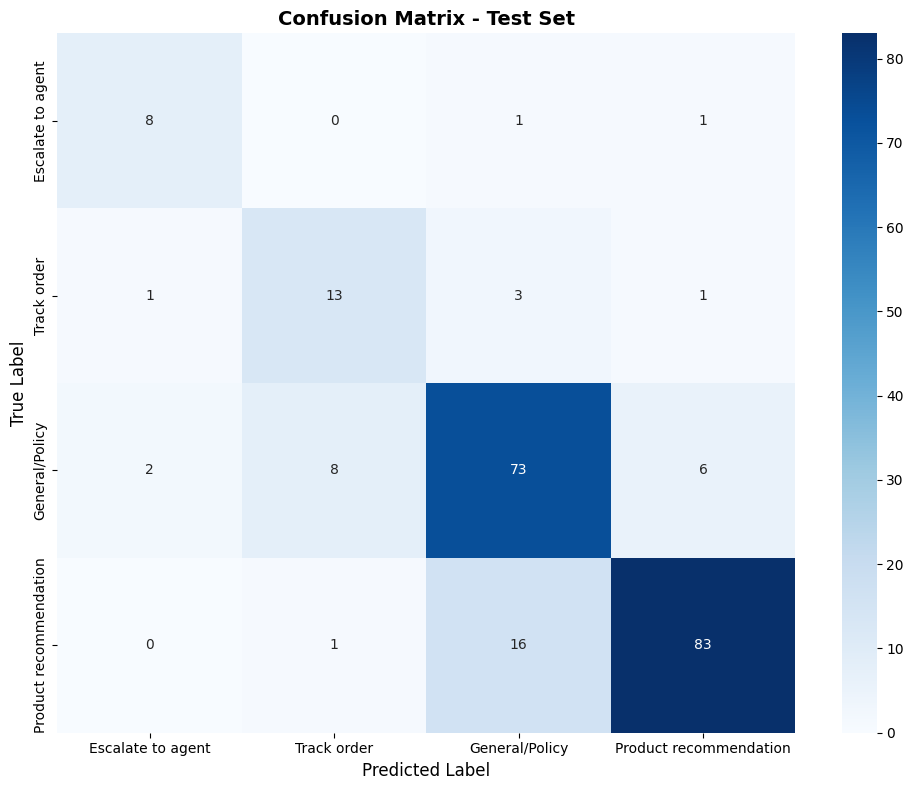


Sample Misclassified Examples:

1. Original: I want gift suggestion for general in all gifts
   True Label: 2 (Product recommendation)
   Predicted: 1 (General/Policy)

2. Original: How to use voucher
   True Label: 2 (Product recommendation)
   Predicted: -1 (Track order)

3. Original: i need two item today or maximum tommorrow morning
   True Label: -1 (Track order)
   Predicted: 1 (General/Policy)

4. Original: Whether store in Delhi
   True Label: -1 (Track order)
   Predicted: -2 (Escalate to agent)

5. Original: Can i get silver bill
   True Label: 1 (General/Policy)
   Predicted: 2 (Product recommendation)


In [34]:
# Confusion Matrix visualization
import seaborn as sns

# Use original labels for confusion matrix
y_test_pred_original = label_encoder.inverse_transform(y_test_pred_encoded)
cm = confusion_matrix(y_test, y_test_pred_original)
labels = sorted(np.unique(y_test))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[label_names[l] for l in labels],
            yticklabels=[label_names[l] for l in labels])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show some misclassified examples
print("\n" + "="*80)
print("Sample Misclassified Examples:")
print("="*80)
misclassified_indices = np.where(y_test != y_test_pred_original)[0]

if len(misclassified_indices) > 0:
    # Get original indices from test set
    test_indices = np.arange(len(dataframe))[np.isin(np.arange(len(dataframe)), 
                                                      dataframe.index[dataframe['label'].isin(y_test)])]
    
    for i, idx in enumerate(misclassified_indices[:5]):  # Show first 5
        print(f"\n{i+1}. Original: {dataframe.iloc[idx]['sentence']}")
        print(f"   True Label: {y_test[idx]} ({label_names[y_test[idx]]})")
        print(f"   Predicted: {y_test_pred_original[idx]} ({label_names[y_test_pred_original[idx]]})")
else:
    print("\n✓ Perfect predictions! No misclassified examples.")

In [36]:
# Inference - Prediction Function
def predict_intent(query):
    """
    Predict the intent label for a given user query.
    
    Parameters:
    -----------
    query : str
        Raw user input text
        
    Returns:
    --------
    dict
        Dictionary containing:
        - 'query': Original input
        - 'processed_query': Preprocessed text
        - 'predicted_label': Numeric label (-2, -1, 1, 2)
        - 'predicted_category': Human-readable category name
        - 'confidence': Prediction probability (if available)
    """
    # Label mapping
    label_names = {
        -2: "Escalate to human agent",
        -1: "Track order/order status (login required)",
        1: "General conversation/company policy",
        2: "Product recommendation"
    }
    
    # Step 1: Preprocess the query
    processed_query = preprocess_text(query)
    
    # Step 2: Vectorize using fitted TF-IDF vectorizer
    query_vector = tfidf_vectorizer.transform([processed_query])
    
    # Step 3: Predict using the trained model
    prediction_encoded = xgb_model.predict(query_vector)[0]
    
    # Step 4: Decode to original label
    prediction_label = label_encoder.inverse_transform([prediction_encoded])[0]
    
    # Step 5: Get prediction probability (confidence)
    prediction_proba = xgb_model.predict_proba(query_vector)[0]
    confidence = prediction_proba[prediction_encoded]
    
    # Return results
    return {
        'query': query,
        'processed_query': processed_query,
        'predicted_label': int(prediction_label),
        'predicted_category': label_names[prediction_label],
        'confidence': float(confidence),
        'all_probabilities': {
            label_names[label_encoder.inverse_transform([i])[0]]: float(prob) 
            for i, prob in enumerate(prediction_proba)
        }
    }


# Helper function for batch predictions
def predict_batch(queries):
    """
    Predict intents for multiple queries at once.
    
    Parameters:
    -----------
    queries : list of str
        List of user queries
        
    Returns:
    --------
    list of dict
        List of prediction results
    """
    return [predict_intent(query) for query in queries]

In [37]:
# Test the prediction function with sample queries
test_queries = [
    "I want gift suggestion for my wife",
    "Track my order GC12345",
    "Can I talk to an agent?",
    "Do you deliver to Mumbai?",
    "Cancel my order"
]

print("="*80)
print("INFERENCE EXAMPLES")
print("="*80)

for query in test_queries:
    result = predict_intent(query)
    print(f"\nQuery: {result['query']}")
    print(f"Processed: {result['processed_query']}")
    print(f"Prediction: {result['predicted_category']} (Label: {result['predicted_label']})")
    print(f"Confidence: {result['confidence']:.2%}")
    print(f"All Probabilities:")
    for category, prob in result['all_probabilities'].items():
        print(f"  - {category}: {prob:.2%}")
    print("-" * 80)

INFERENCE EXAMPLES

Query: I want gift suggestion for my wife
Processed: want gift suggestion wife
Prediction: Product recommendation (Label: 2)
Confidence: 99.55%
All Probabilities:
  - Escalate to human agent: 0.07%
  - Track order/order status (login required): 0.04%
  - General conversation/company policy: 0.34%
  - Product recommendation: 99.55%
--------------------------------------------------------------------------------

Query: Track my order GC12345
Processed: track order gc12345
Prediction: Track order/order status (login required) (Label: -1)
Confidence: 99.44%
All Probabilities:
  - Escalate to human agent: 0.05%
  - Track order/order status (login required): 99.44%
  - General conversation/company policy: 0.44%
  - Product recommendation: 0.08%
--------------------------------------------------------------------------------

Query: Can I talk to an agent?
Processed: talk agent
Prediction: Escalate to human agent (Label: -2)
Confidence: 97.98%
All Probabilities:
  - Escal

In [38]:
# Test with user's problematic queries
problematic_queries = [
    "recommend me something for my girlfriend",
    "recommend a gift for Diwali",
    "a product to track my health",
    "something to track my health",
    "something to wear",
    "something to eat",
    "gold necklace suggestions"
]

print("="*80)
print("TESTING PROBLEMATIC QUERIES (After Retraining)")
print("="*80)

for query in problematic_queries:
    result = predict_intent(query)
    print(f"\nQuery: {result['query']}")
    print(f"Prediction: {result['predicted_category']} (Label: {result['predicted_label']})")
    print(f"Confidence: {result['confidence']:.2%}")
    print("-" * 80)

TESTING PROBLEMATIC QUERIES (After Retraining)

Query: recommend me something for my girlfriend
Prediction: Product recommendation (Label: 2)
Confidence: 98.18%
--------------------------------------------------------------------------------

Query: recommend a gift for Diwali
Prediction: Product recommendation (Label: 2)
Confidence: 57.51%
--------------------------------------------------------------------------------

Query: a product to track my health
Prediction: Product recommendation (Label: 2)
Confidence: 52.53%
--------------------------------------------------------------------------------

Query: something to track my health
Prediction: Product recommendation (Label: 2)
Confidence: 98.93%
--------------------------------------------------------------------------------

Query: something to wear
Prediction: Product recommendation (Label: 2)
Confidence: 96.72%
--------------------------------------------------------------------------------

Query: something to eat
Prediction: P

In [39]:
while True:
    user_input = input("\nEnter a query to predict intent (or 'exit' to quit): ")
    if user_input.lower() == 'exit':
        print("Exiting inference.")
        break
    prediction = predict_intent(user_input)
    print(f"\nQuery: {prediction['query']}")
    print(f"\nPredicted Intent: {prediction['predicted_category']} (Label: {prediction['predicted_label']})")
    print(f"Confidence: {prediction['confidence']:.2%}")


Query: got something for winter?

Predicted Intent: Product recommendation (Label: 2)
Confidence: 96.72%

Query: anything for winter?

Predicted Intent: Product recommendation (Label: 2)
Confidence: 80.88%

Query: what to wear in winter

Predicted Intent: General conversation/company policy (Label: 1)
Confidence: 70.70%

Query: i will kil you

Predicted Intent: General conversation/company policy (Label: 1)
Confidence: 70.70%

Query: compare ring prices

Predicted Intent: General conversation/company policy (Label: 1)
Confidence: 70.70%

Query: rings for sale?

Predicted Intent: General conversation/company policy (Label: 1)
Confidence: 70.70%

Query: do you have rings?

Predicted Intent: General conversation/company policy (Label: 1)
Confidence: 70.70%

Query: show me some rings

Predicted Intent: Product recommendation (Label: 2)
Confidence: 93.16%

Query: show me some neclaces

Predicted Intent: Product recommendation (Label: 2)
Confidence: 93.16%

Query: any good necklaces

Predic

These are still being classified wrong. What could be the reason? 
Query: recommend me something for my girlfriend

Predicted Intent: General conversation/company policy (Label: 1)
Confidence: 75.25%

Query: recommend a gift for Diwali

Predicted Intent: Product recommendation (Label: 2) [This is somehow correct !? Maybe it is looking at gift +. recommend, dont know. But people wont always call it a gift.]
Confidence: 69.92%

Query: a product to track my health.

Predicted Intent: General conversation/company policy (Label: 1)
Confidence: 92.31%
Exiting inference. 

Query: something to track my health.

Predicted Intent: General conversation/company policy (Label: 1)
Confidence: 75.13% 

Query: something to wear

Predicted Intent: General conversation/company policy (Label: 1)
Confidence: 75.25% 

